The input files should first be interpolated onto a common grid in order to compare them

# Imports

In [1]:
import os
import glob
import numpy as np
import xarray as xr
import cf_xarray as cfxr
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

from urclimask.urban_areas import UrbanVicinity
from urclimask.utils import (
    kelvin2degC,
    fix_360_longitudes,
)

In [2]:
# pip install papermill

# Variables:

In [3]:
## General configuration

# file = 'tsl_ALPX-3f_ERA5_evaluation_r1i1p1f1_BCCR-UCAN_WRF451R-CI4C_v1-r1_6hr_199901010000-199912311800.nc'
file = 'tas_ALPX-3f_ERA5_evaluation_r1i1p1f1_BCCR-UCAN_WRF451R-CI4C_v1-r1_1hr_199901010000-199912312300.nc'

# City information
city = "Paris"
lon_city = 2.35
lat_city = 48.85

# Root folder where the model data are stored
root_nextcloud = '../I4C_CPRCM_DATA/'

# Path and file name of the official city boundary polygons file
city_polygon_path = '../utils/'
poligon_info_file = 'city_polygons_clean_file.gpkg'

In [4]:
##Information obtained from the file name:
variable, domain, driving_model, scenario, member, institution, model, version, time_interval, time_period = file.split("_")

In [5]:
## Mask configuration

# Mask parameters
urban_th = 60
urban_sur_th = 15
orog_diff = 100
sftlf_th = 70
ratio_r2u = 1  # Rural cell number per urban one
min_city_size = 80  # Minimum number of grid points required for the city
lon_lim = 0.7
lat_lim = 0.7

domain_resolution = 3  # In km
urban_var = 'sfturf'  # Name of the urban-rural field introduced in the model

file_sfturf = glob.glob(f"{root_nextcloud}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/fx/sfturf/*/*.nc")
file_orog = glob.glob(f"{root_nextcloud}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/fx/orog/*/*.nc")
file_sftlf = glob.glob(f"{root_nextcloud}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/fx/sftlf/*/*.nc")

# Masks obtention

In [6]:
#Folder to save masks
output_dir = '../utils/urclimask_Results'# Name of the output directory
os.makedirs(output_dir, exist_ok = True) #The directory is only created if it does'nt exist

In [7]:
path_name_mask = f"{output_dir}/{city}-{domain}_{model}_urban_rural_mask.nc" #Masks file names

if os.path.isfile(path_name_mask):
    print("The mask already exists")
    urmask = xr.open_dataset(path_name_mask)
else:
    #Open fields datasets
    ds_sfturf = xr.open_dataset(file_sfturf[0])
    ds_orog = xr.open_dataset(file_orog[0])
    ds_sftlf = xr.open_dataset(file_sftlf[0])

    ds_sfturf = fix_360_longitudes(ds_sfturf)#Repository's urclimask function. It's defined in urclimask/utils.py. 
                                            #It converts longitudes from 0–360° to -180–180°
    ds_orog = fix_360_longitudes(ds_orog)
    ds_sftlf = fix_360_longitudes(ds_sftlf)

    #It creates the object urban from UrbanVicinity (urclimask repository)
    URBAN = UrbanVicinity(
        urban_sur_th = urban_sur_th,
        orog_diff = orog_diff,
        sftlf_th = sftlf_th,
        ratio_r2u = ratio_r2u,
        min_city_size = min_city_size,
        lon_city = lon_city,
        lat_city = lat_city,
        lon_lim = lon_lim,
        lat_lim = lat_lim,
        model = model,
        domain = domain,
        urban_th = urban_th,
        urban_var = urban_var
    )

    # Crop area around de city in the fields datasets
    ds_sfturf = URBAN.crop_area_city(ds = ds_sfturf, res = domain_resolution)
    ds_orog = URBAN.crop_area_city(ds = ds_orog, res = domain_resolution)
    ds_sftlf = URBAN.crop_area_city(ds = ds_sftlf, res = domain_resolution)

    # Define masks using the parameters above
    sfturf_mask, sfturf_sur_mask, orog_mask, sftlf_mask = URBAN.define_masks(
        ds_sfturf = ds_sfturf, #
        ds_orog = ds_orog, 
        ds_sftlf = ds_sftlf,
    )

    # sfturf_mask: Urban mask, identifies urban grid cells based on the urban variable (sftimf) and the defined urban threshold (urban_th).
    # sfturf_sur_mask: Urban surroundings mask, identifies grid cells in the transition zone between urban and rural areas based on the urban surface threshold (urban_sur_th).
    # orog_mask: Orography mask, identifies grid cells where the elevation difference is less than the defined threshold (orog_diff). 

    ## Final rural-urban mask:
    # Starting from the city, it progressively expands the surrounding area until it finds enough comparable rural cells, 
    # excluding sea, areas with non-comparable orography, and peri-urban zones.
    urmask = URBAN.select_urban_vicinity(
        sfturf_mask = sfturf_mask, 
        orog_mask = orog_mask,
        sftlf_mask = sftlf_mask,
        sfturf_sur_mask = sfturf_sur_mask
    )
    #ratio_r2u-> Criteria for enough riral cells, predefined (self)

    ##Save the mask in a netcdf file
    urmask.urmask.to_netcdf(path_name_mask)

    print("The file did not exist, so it was calculated and saved.")
    

The mask already exists


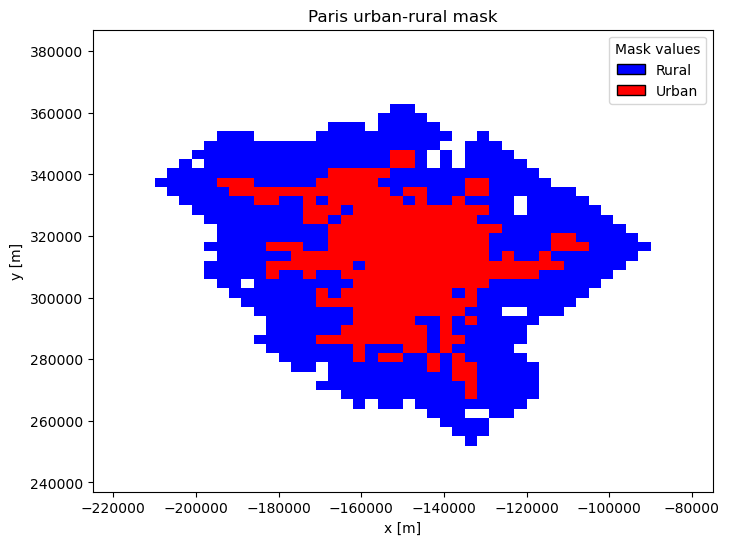

In [8]:
##Mask representation:

#It assign colors to the values
# 0 = rural, 1 = urban
cmap = ListedColormap(["blue", "red"])#Color list definition
norm = BoundaryNorm([-0.5, 0.5, 1.5], cmap.N)#It divide the colorbar into two parts, one for each value (0 and 1

fig, ax = plt.subplots(figsize=(8, 6))#plot size

urmask.urmask.plot(ax=ax, cmap=cmap, norm=norm, add_colorbar=False) #It plots the mask without colorbar, with the defined colors

ax.set_title(f"{city} urban-rural mask")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")

# Manual legend with the same colors as the map
legend_elements = [mpatches.Patch(facecolor="blue", edgecolor="black", label="Rural"),
    mpatches.Patch(facecolor="red", edgecolor="black", label="Urban"),]
ax.legend(handles=legend_elements, title="Mask values", loc="upper right")

plt.show()

# Mean heat/humidity island:

In [9]:
#City and rural variable differences: Urban heat islan/ humidity island 

## Mean variable over urban points
urban_mask = urmask.urmask == 1#Urban mask definition

#Find file:
files = glob.glob(f"{root_nextcloud}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/{time_interval}/{variable}/{file}")
if files==[]:#There are some cases where the file is stored in a subfolder
    files = glob.glob(f"{root_nextcloud}{domain}/{institution}/{driving_model}/{scenario}/{member}/{model}/{version}/{time_interval}/{variable}/*/{file}")

#Open file, change units and longitudes
ds = xr.open_dataset(files[0])#because glob.glob return a list of files
ds = kelvin2degC(ds, variable)#K->ºC
ds = fix_360_longitudes(ds)#0–360 -> -180–180

#Selection of urban points and calculation of the mean
variable_city = ds[variable].where(urban_mask)
variable_city_mean = float(variable_city.mean())

## Mean variable over rural points:
urban_mask = urmask.urmask == 0#Rural mask definition
variable_rural = ds[variable].where(urban_mask) #Selection of urban points
variable_rural_mean = float(variable_rural.mean())  #Calculation of the mean

variable_dif = variable_city_mean-variable_rural_mean
print('Difference between the urban mean value and the rural one: ', variable_dif)


Difference between the urban mean value and the rural one:  0.4216184616088867


# Urban and rural variable values with the official city boundary

In [10]:
#City polygon extraction

#Read file
gdf = gpd.read_file(city_polygon_path+poligon_info_file)

# #clean the geopandas file: Only did it onces.
# # Remove \ufeff from colum names
# ucdb_info .columns = [col.lstrip("\ufeff") for col in ucdb_info.columns]
# # Save the clean file:
# ucdb_info .to_file("archivo_limpio.gpkg", driver="GPKG")#to save as geopandas file

#Find the city in the file:
matches = gdf[gdf["GC_UCN_MAI_2025"].astype(str).str.contains(city, case=False, na=False)]
# matches



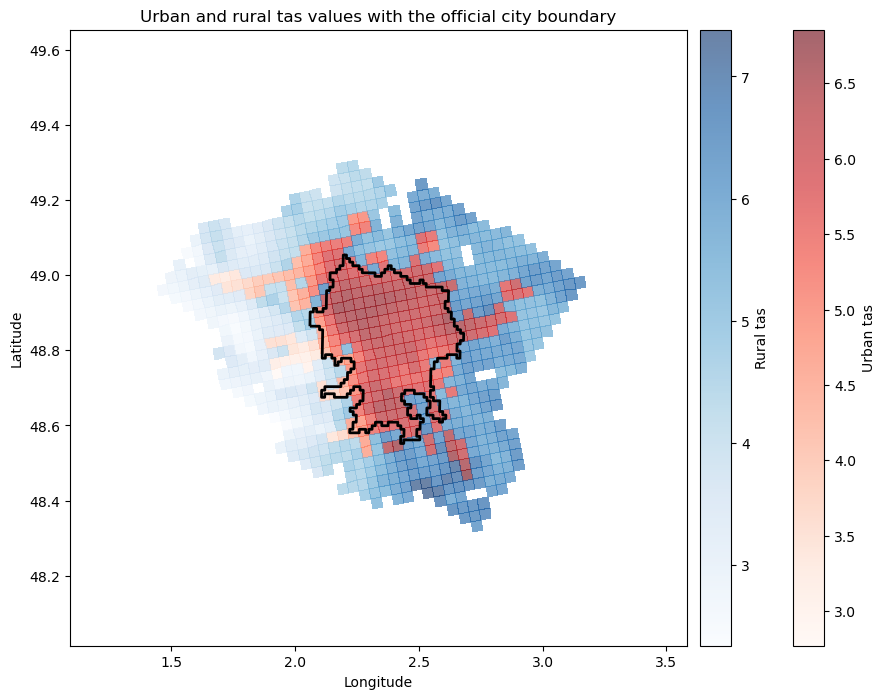

Difference between the urban mean  tas  value and the rural one:  0.4216184616088867


In [11]:
##Figure:

fig, ax = plt.subplots(figsize=(10, 8))

#Take a time and sdepth to represent (adapt to variable coordinates)
urban = variable_city.isel(time=0)
rural = variable_rural.isel(time=0)

# First plot layer
im1 = ax.pcolormesh(urban.lon, urban.lat, urban, cmap="Reds", alpha=0.6, shading="auto", zorder=1)

# Second plot layer
im2 = ax.pcolormesh(rural.lon, rural.lat, rural, cmap="Blues", alpha=0.6, shading="auto", zorder=2)

# City poligon in lon/lat
matches_lonlat = matches.to_crs("EPSG:4326")#Change the geopandas (city polygon) coordinates

#Third plot layer
matches_lonlat.boundary.plot(ax=ax, color="black", linewidth=2, zorder=10)

# Color bars:
cbar1 = plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.08)#urban
label1_str="Urban "+ variable
cbar1.set_label(label1_str)

cbar2 = plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.02)#rural
label2_str="Rural "+ variable
cbar2.set_label(label2_str)

#labels and title
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
title_str='Urban and rural '+variable+' values with the official city boundary'
ax.set_title(title_str)

plt.show()
print('Difference between the urban mean ',variable, ' value and the rural one: ', variable_dif)


# Diurnal cicle:

In [12]:
#Representations function:

def plot_diurnal_cycle(var, title):
    #Promediate over the spatial dimensions (x, y)
    diurnal_cycle = var.mean(dim='x').mean(dim='y')

    #Transform time coordinate to datetime
    diurnal_cycle = diurnal_cycle.assign_coords(
        time=np.array([
            np.datetime64(f"{t.year:04d}-{t.month:02d}-{t.day:02d}T{t.hour:02d}:{t.minute:02d}:{t.second:02d}")
            for t in diurnal_cycle.time.values]))
    
    #Promediate over the time dimension to get the diurnal cicle, in our case hour by hour
    diurnal_cycle = diurnal_cycle.groupby('time.hour').mean(dim='time')

    #If the data is 6-hourly, the plot will show only 4 points.
    #If the data is hourly, the plot will show 24 points, giving a better representation.

    #Diurnal cicle plot:
    diurnal_cycle.plot()
    plt.title(title)
    plt.xlabel('t / hours')
    plt.ylabel(f"{variable} / {diurnal_cycle.attrs['units']}")
    return diurnal_cycle




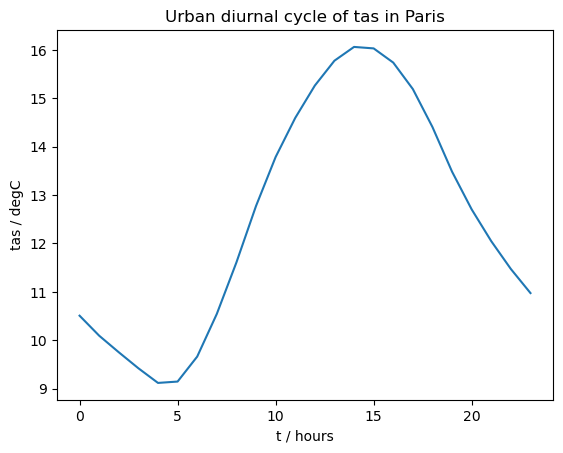

In [13]:
#Plot the diurnal cycle for the urban area
urban_cycle=plot_diurnal_cycle(var=variable_city, title=f"Urban diurnal cycle of {variable} in {city}")


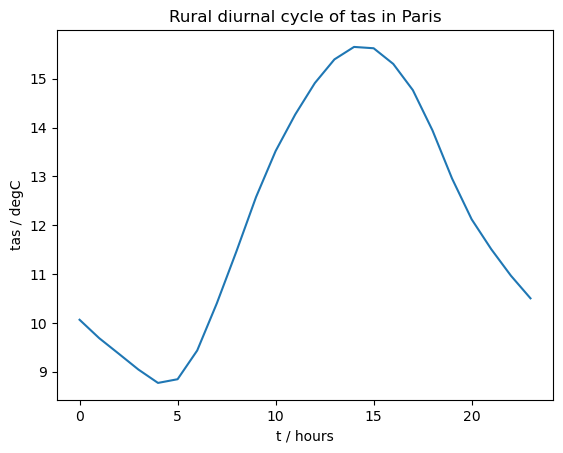

In [14]:
#Plot the diurnal cycle for the rural area around the city
rural_cycle=plot_diurnal_cycle(var=variable_rural, title=f"Rural diurnal cycle of {variable} in {city}")

Text(0, 0.5, 'tas / degC')

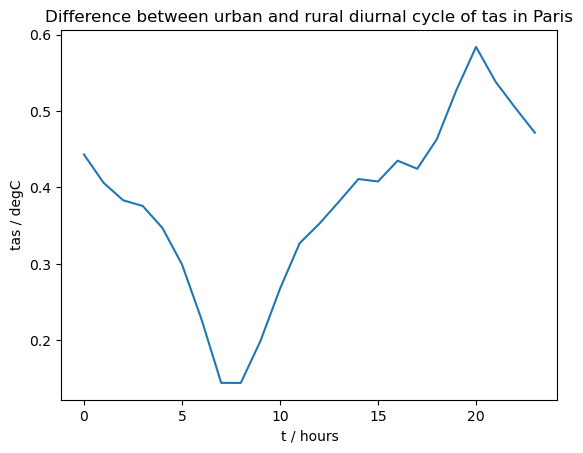

In [15]:
##DIFFERENCE BETWEEN URBAN AND RURAL DIURNAL CICLE:
diurnal_cycle_diff=urban_cycle-rural_cycle
diurnal_cycle_diff.plot()
plt.title(f"Difference between urban and rural diurnal cycle of {variable} in {city}")
plt.xlabel('t / hours')
plt.ylabel(f"{variable} / {urban_cycle.attrs['units']}")

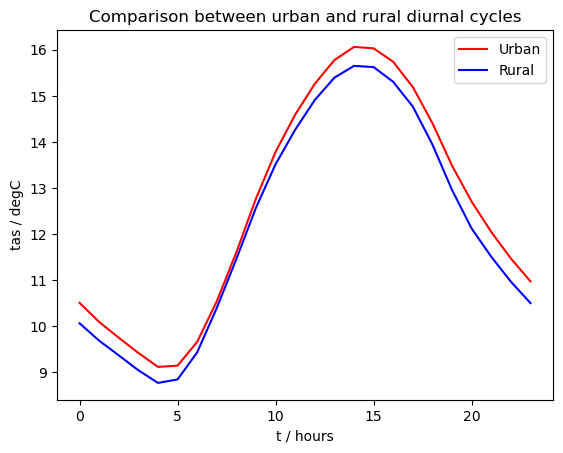

In [16]:
#Comparison between urban and rural diurnal cycles:
urban_cycle.plot(label="Urban", color="red")
rural_cycle.plot(label="Rural", color="blue")
plt.title('Comparison between urban and rural diurnal cycles')
plt.xlabel('t / hours')
plt.ylabel(f"{variable} / {urban_cycle.attrs['units']}")
plt.legend()
